<a href="https://colab.research.google.com/github/KK-code001/Candidate-Screening-System/blob/main/Combined_ROC_AUC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load Train and Test Datasets
Please upload your train and test datasets (e.g., as CSV files) or specify their paths below. Make sure your datasets have feature columns and a target column. If your data is in a different format, please modify the loading code accordingly.

In [12]:
import pandas as pd

# --- User Input Required ---
# Replace 'path/to/your_train_data.csv' with the actual path to your training dataset
# If your data is not in CSV format, modify pd.read_csv to the appropriate loading function (e.g., pd.read_excel, pd.read_sql, etc.)
try:
    train_df = pd.read_csv('/content/train_data.csv')
    print("Train data loaded successfully.")
    display(train_df.head())
except FileNotFoundError:
    print("Train data file not found. Please update the path to your training dataset.")
    train_df = None # Set to None to indicate no data loaded

# Replace 'path/to/your_test_data.csv' with the actual path to your test dataset
try:
    test_df = pd.read_csv('/content/test_data.csv')
    print("Test data loaded successfully.")
    display(test_df.head())
except FileNotFoundError:
    print("Test data file not found. Please update the path to your test dataset.")
    test_df = None # Set to None to indicate no data loaded

if train_df is not None and test_df is not None:
    # --- User Input Required ---
    # Specify the name of your target column
    TARGET_COLUMN = 'shortlisted' # e.g., 'target', 'label', 'is_fraud' - Please update this with your actual target column name

    # Ensure the target column exists in both dataframes
    if TARGET_COLUMN not in train_df.columns:
        print(f"Error: Target column '{TARGET_COLUMN}' not found in the training data. Please update `TARGET_COLUMN`.")
        train_df = None
    if TARGET_COLUMN not in test_df.columns:
        print(f"Error: Target column '{TARGET_COLUMN}' not found in the test data. Please update `TARGET_COLUMN`.")
        test_df = None

    if train_df is not None and test_df is not None:
        X_train = train_df.drop(columns=[TARGET_COLUMN])
        y_train = train_df[TARGET_COLUMN]
        X_test = test_df.drop(columns=[TARGET_COLUMN])
        y_test = test_df[TARGET_COLUMN]

        print("\nFeatures (X_train) and Target (y_train) for training:")
        print(f"X_train shape: {X_train.shape}")
        print(f"y_train shape: {y_train.shape}")
        print("\nFeatures (X_test) and Target (y_test) for testing:")
        print(f"X_test shape: {X_test.shape}")
        print(f"y_test shape: {y_test.shape}")

else:
    print("Skipping model building as datasets were not loaded correctly.")

Train data loaded successfully.


,years_experience,education_level,project_count,resume_length,github_activity,shortlisted
0,12,Masters,13,717,469,Yes
1,8,Bachelors,10,595,418,Yes
2,3,Masters,8,303,195,Yes
3,14,PhD,14,770,435,Yes
4,5,Masters,10,277,255,Yes


Test data loaded successfully.


,years_experience,education_level,project_count,resume_length,github_activity,shortlisted
0,14,High School,16,759,589,Yes
1,13,High School,11,751,414,Yes
2,10,PhD,12,600,464,Yes
3,6,Bachelors,9,586,325,Yes
4,5,Masters,15,412,442,Yes



Features (X_train) and Target (y_train) for training:
X_train shape: (24000, 5)
y_train shape: (24000,)

Features (X_test) and Target (y_test) for testing:
X_test shape: (6000, 5)
y_test shape: (6000,)


In [13]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})
print("Target labels converted to numerical (0 for 'No', 1 for 'Yes').")

Target labels converted to numerical (0 for 'No', 1 for 'Yes').


### Data Preprocessing and Model Training
Before training the models, it's often necessary to preprocess the data (e.g., handle missing values, encode categorical features, scale numerical features). For simplicity, we'll proceed assuming basic preprocessing is done or not strictly required for initial model training. If your data requires more complex preprocessing, you might need to add those steps here.

First, let's import the necessary libraries and define a helper function to train models and collect their ROC curve data.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

import matplotlib.pyplot as plt
import numpy as np

def train_evaluate_model(model_name, model, X_train, y_train, X_test, y_test, preprocessor=None):
    """
    Trains a given model, makes predictions, and returns ROC curve data and AUC score.
    """
    print(f"\n--- Training {model_name} ---")
    if preprocessor:
        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
        pipeline.fit(X_train, y_train)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    roc_auc_s = roc_auc_score(y_test, y_pred_proba)
    print(f"{model_name} ROC-AUC Score: {roc_auc_s:.4f}")

    return fpr, tpr, roc_auc_s

# This is a placeholder for preprocessing steps.
# You might need to adjust this based on your data types and features.
# Example: Identify numerical and categorical features
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

# Create a preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

### Train Models and Collect ROC Data
Now, let's define and train each of the requested models and collect their ROC curve data.

In [15]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Linear SVM': SVC(kernel='linear', probability=True, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

roc_data = {}
for name, model in models.items():
    fpr, tpr, roc_auc_s = train_evaluate_model(name, model, X_train, y_train, X_test, y_test, preprocessor)
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc_s}


--- Training Logistic Regression ---
Logistic Regression ROC-AUC Score: 0.9559

--- Training Linear SVM ---
Linear SVM ROC-AUC Score: 0.9559

--- Training KNN (k=5) ---
KNN (k=5) ROC-AUC Score: 0.9233

--- Training Decision Tree ---
Decision Tree ROC-AUC Score: 0.8201

--- Training Random Forest ---
Random Forest ROC-AUC Score: 0.9483

--- Training XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:08:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost ROC-AUC Score: 0.9560


### Combined ROC-AUC Curve
Finally, let's plot all the ROC curves on a single graph for comparison.

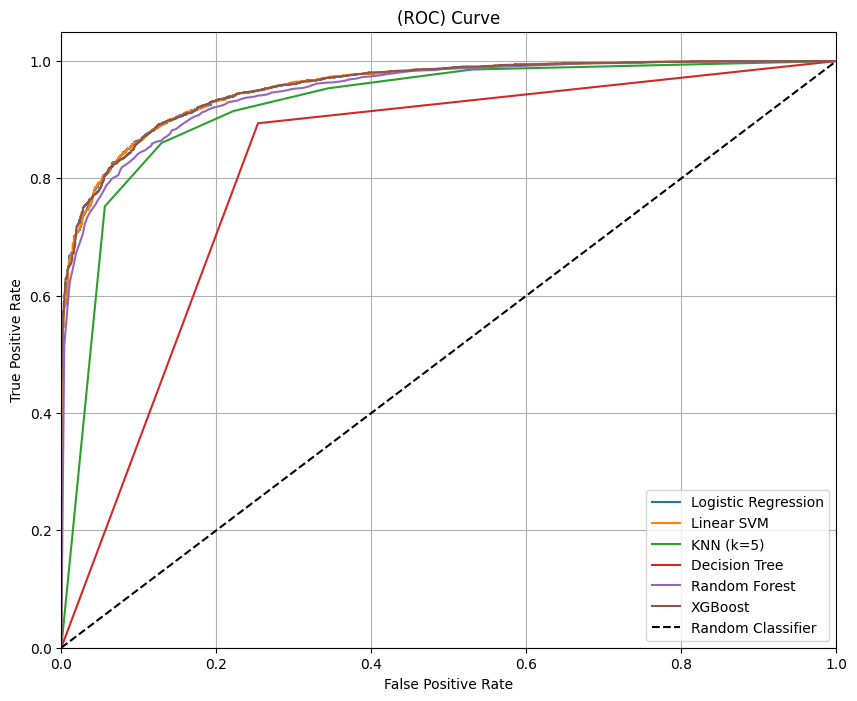

In [21]:
plt.figure(figsize=(10, 8))
for name, data in roc_data.items():
    plt.plot(data['fpr'], data['tpr'], label=f'{name}')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()